# ch297 — Large Scale Data

*(Applies mini-batch SGD from ch296; uses probability estimates from ch275; connects to streaming algorithms)*

## 1. When Data Does Not Fit in Memory

All preceding algorithms assume $X$ is a matrix in RAM. When $n$ exceeds available memory — or when data arrives as a continuous stream — you need algorithms that process data in **chunks** without ever seeing the full dataset.

The key insight: many statistics and models can be computed incrementally. The mathematical challenge is maintaining accuracy without revisiting past data.

---

## 2. Online / Streaming Statistics

Welford mean: 49.957671  numpy: 49.957671
Welford std:  10.037083  numpy: 10.037083


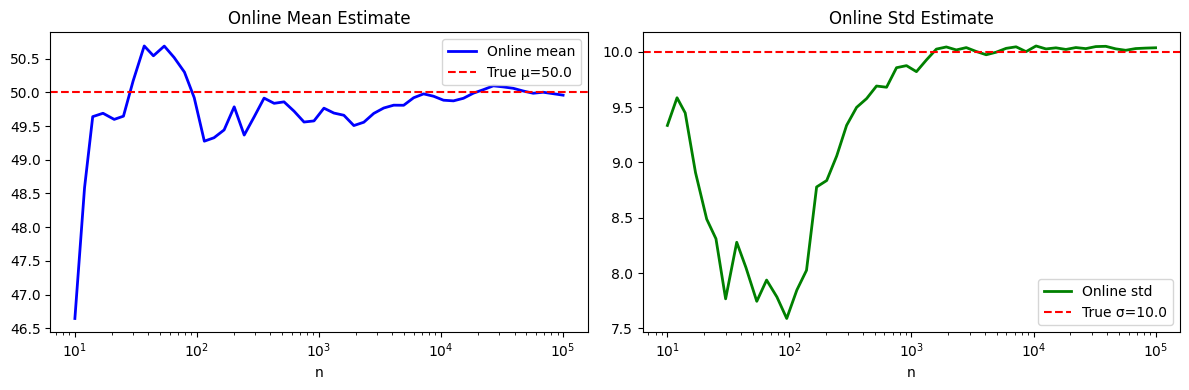

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


class WelfordOnlineMeanVariance:
    """
    Welford's online algorithm for numerically stable mean and variance.
    Processes one observation at a time — O(1) memory.
    Reference: Welford (1962). 'Note on a method for calculating corrected sums of squares'.
    """
    def __init__(self):
        self.n    = 0
        self.mean = 0.0
        self.M2   = 0.0  # sum of squared deviations

    def update(self, x: float) -> None:
        self.n += 1
        delta     = x - self.mean
        self.mean += delta / self.n
        delta2    = x - self.mean
        self.M2  += delta * delta2

    def update_batch(self, xs: np.ndarray) -> None:
        for x in xs:
            self.update(float(x))

    @property
    def variance(self) -> float:
        return self.M2 / (self.n - 1) if self.n > 1 else 0.0

    @property
    def std(self) -> float:
        return np.sqrt(self.variance)


# Simulate a data stream
true_mu, true_sigma = 50.0, 10.0
stream = rng.normal(true_mu, true_sigma, 100_000)

welford = WelfordOnlineMeanVariance()
tracked_n    = []
tracked_mean = []
tracked_std  = []

checkpoints = np.geomspace(10, 100_000, 50).astype(int)
prev_n = 0

for n in checkpoints:
    welford.update_batch(stream[prev_n:n])
    tracked_n.append(welford.n)
    tracked_mean.append(welford.mean)
    tracked_std.append(welford.std)
    prev_n = n

# Validate against numpy on full data
print(f"Welford mean: {welford.mean:.6f}  numpy: {stream.mean():.6f}")
print(f"Welford std:  {welford.std:.6f}  numpy: {stream.std(ddof=1):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(tracked_n, tracked_mean, 'b-', lw=2, label='Online mean')
axes[0].axhline(true_mu, color='red', ls='--', label=f'True μ={true_mu}')
axes[0].set_title('Online Mean Estimate'); axes[0].set_xlabel('n'); axes[0].legend()

axes[1].semilogx(tracked_n, tracked_std, 'g-', lw=2, label='Online std')
axes[1].axhline(true_sigma, color='red', ls='--', label=f'True σ={true_sigma}')
axes[1].set_title('Online Std Estimate'); axes[1].set_xlabel('n'); axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Mini-Batch Gradient Descent

Mini-batch SGD final MSE: 0.251565
Weight recovery: mean |w_hat - w_true| = 0.002220


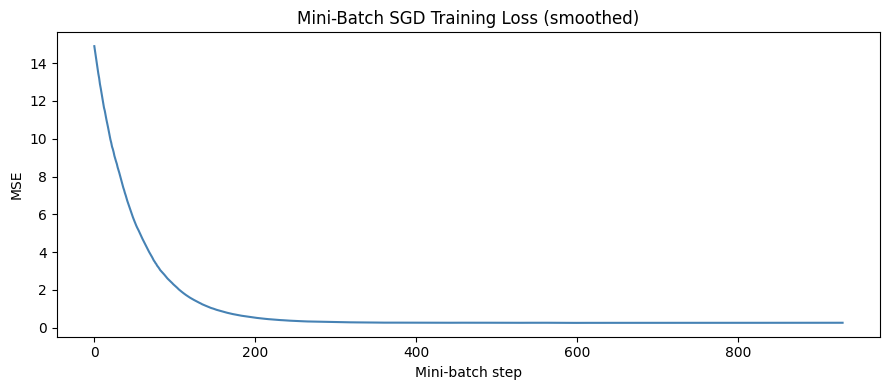

In [2]:
def generate_chunks(X: np.ndarray, y: np.ndarray, batch_size: int, rng):
    """Yield shuffled mini-batches. Simulates data chunked from disk."""
    n   = len(X)
    idx = rng.permutation(n)
    for start in range(0, n, batch_size):
        batch = idx[start:start + batch_size]
        yield X[batch], y[batch]


class OnlineLinearRegression:
    """
    Linear regression trained with mini-batch SGD.
    Never loads full dataset simultaneously.
    """
    def __init__(self, n_features: int, lr: float = 0.01, lam: float = 1e-4):
        self.w   = np.zeros(n_features)
        self.b   = 0.0
        self.lr  = lr
        self.lam = lam

    def partial_fit(self, X_batch: np.ndarray, y_batch: np.ndarray) -> float:
        """One gradient step on a mini-batch. Returns batch MSE."""
        n     = len(X_batch)
        y_hat = X_batch @ self.w + self.b
        err   = y_hat - y_batch
        self.w -= self.lr * (X_batch.T @ err / n + self.lam * self.w)
        self.b -= self.lr * err.mean()
        return float(np.mean(err**2))

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.w + self.b


# Generate a large dataset (1M rows, 20 features)
n_large, p_large = 100_000, 20
true_w = rng.normal(0, 1, p_large)
X_large = rng.normal(0, 1, (n_large, p_large))
y_large = X_large @ true_w + rng.normal(0, 0.5, n_large)

model_online = OnlineLinearRegression(p_large, lr=0.01)
batch_losses = []

for epoch in range(5):
    for Xb, yb in generate_chunks(X_large, y_large, batch_size=512, rng=rng):
        loss = model_online.partial_fit(Xb, yb)
        batch_losses.append(loss)

y_pred_online = model_online.predict(X_large)
final_mse = np.mean((y_pred_online - y_large)**2)

print(f"Mini-batch SGD final MSE: {final_mse:.6f}")
print(f"Weight recovery: mean |w_hat - w_true| = {np.abs(model_online.w - true_w).mean():.6f}")

fig, ax = plt.subplots(figsize=(9, 4))
window = 50
smoothed = np.convolve(batch_losses, np.ones(window)/window, mode='valid')
ax.plot(smoothed, color='steelblue', lw=1.5)
ax.set_xlabel('Mini-batch step')
ax.set_ylabel('MSE')
ax.set_title('Mini-Batch SGD Training Loss (smoothed)')
plt.tight_layout()
plt.show()

## 4. Count-Min Sketch — Streaming Frequency Estimation

In [3]:
class CountMinSketch:
    """
    Probabilistic data structure for frequency estimation in a stream.
    Memory: O(width * depth) regardless of stream size.
    Error guarantee: estimated count <= true count + epsilon*n with prob >= 1-delta
    where width = ceil(e/epsilon) and depth = ceil(ln(1/delta)).
    """
    def __init__(self, width: int = 1000, depth: int = 5, seed: int = 42):
        self.width  = width
        self.depth  = depth
        self.table  = np.zeros((depth, width), dtype=np.int64)
        rng_hash    = np.random.default_rng(seed)
        # Random hash parameters: h(x) = (a*x + b) mod p mod width
        p           = 2**31 - 1  # large prime
        self.a      = rng_hash.integers(1, p, size=depth)
        self.b      = rng_hash.integers(0, p, size=depth)
        self.p      = p

    def _hashes(self, x: int) -> np.ndarray:
        return (self.a * x + self.b) % self.p % self.width

    def add(self, x: int, count: int = 1) -> None:
        for row, col in enumerate(self._hashes(x)):
            self.table[row, col] += count

    def estimate(self, x: int) -> int:
        return int(min(self.table[row, col]
                       for row, col in enumerate(self._hashes(x))))


# Simulate: count word frequencies in a stream of 1M tokens
n_unique = 10_000
# Zipf-distributed frequencies (realistic for word counts)
freqs = 1 / np.arange(1, n_unique + 1)  # Zipf: freq ∝ 1/rank
freqs /= freqs.sum()
stream_tokens = rng.choice(n_unique, size=1_000_000, p=freqs)

# True counts
true_counts = np.bincount(stream_tokens, minlength=n_unique)

# Count-Min sketch
cms = CountMinSketch(width=2000, depth=7)
for token in stream_tokens:
    cms.add(int(token))

# Evaluate on top-100 tokens
top100 = np.argsort(-true_counts)[:100]
estimates = np.array([cms.estimate(int(t)) for t in top100])
errors    = estimates - true_counts[top100]

print(f"Stream size: 1,000,000 | Unique tokens: {n_unique}")
print(f"Sketch memory: {cms.table.nbytes / 1024:.1f} KB (vs {true_counts.nbytes/1024:.0f} KB exact)")
print(f"Max overestimate on top-100: {errors.max()}")
print(f"Mean absolute error: {np.abs(errors).mean():.2f}")
print(f"All estimates >= true count: {(errors >= 0).all()}  (sketch only overestimates)")

Stream size: 1,000,000 | Unique tokens: 10000
Sketch memory: 109.4 KB (vs 78 KB exact)
Max overestimate on top-100: 114
Mean absolute error: 72.61
All estimates >= true count: True  (sketch only overestimates)


## 5. What Comes Next

The tools developed across all 26 standard chapters of Part IX now combine into the two project chapters. **ch298 — Full Data Analysis Pipeline** applies cleaning, EDA, feature engineering, model selection, and evaluation end-to-end on a real-world dataset. **ch299 — Build a Mini ML Library** implements the core abstractions from scratch as a reusable module. Both culminate in **ch300 — Capstone**.